# Project 7 — main_report: Reproducible Evaluation
**Group 4** — Karan Rooprai (n12498122), Nhu Hieu Nguyen (n12194778)

Loads the two trained DDPM checkpoints and reproduces every figure and number in the report: the 12x10 (120-image) conditional grid for both schedules, and the core test of the hypothesis — sample quality (classifier recognisability) as a function of the number of reverse sampling steps. Runs top-to-bottom in the IFN680 environment; it loads weights and trains only the small evaluation classifier if its cache is absent.

## Setup, data, schedules, model, sampler

In [1]:
# --- Standard stack, matching the Week 9 diffusion tutorial -------------------
import os, math, time, pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import utils
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# --- Reproducibility ---------------------------------------------------------
SEED = 680
np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# --- Hardware (the brief requires .to(device)) -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | device = {device}")

# --- Shared experiment constants ---------------------------------------------
TIMESTEPS   = 1000   # diffusion length T used for TRAINING both models
IMG_SIZE    = 20     # the custom dataset is 20x20 (not 28x28)
CHANNELS    = 1
NUM_CLASSES = 10

PyTorch 2.13.0+cu126 | device = cuda


In [2]:
# ---------------------------------------------------------------------------
# Load the provided custom MNIST (dict of tensors: 20x20, values in [0,1]) and
# rescale to [-1, 1] exactly as the tutorial does (x*2 - 1), so the forward
# process ends at ~N(0, I). We keep the whole training set on the GPU and draw
# batches by indexing: with 60k tiny 20x20 images this removes the DataLoader
# bottleneck and keeps training GPU-bound.
# ---------------------------------------------------------------------------
DATA_PATH = next((p for p in ["mnist_custom.pt", "mnist_custom-1.pt"]
                  if os.path.exists(p)), "mnist_custom.pt")
BATCH_SIZE = 256

blob = torch.load(DATA_PATH, map_location="cpu")
train_x = (blob["train_images"].float() * 2 - 1).to(device)   # (60000,1,20,20) in [-1,1]
train_y = blob["train_labels"].long().to(device)
test_x  = (blob["test_images"].float() * 2 - 1).to(device)
test_y  = blob["test_labels"].long().to(device)
N_TRAIN = train_x.shape[0]
print("train:", tuple(train_x.shape), "range [%.1f, %.1f]" % (train_x.min(), train_x.max()))

def iterate_batches(generator):
    """Yield (x0, labels) batches by shuffling GPU-resident indices each epoch."""
    perm = torch.randperm(N_TRAIN, generator=generator, device=device)
    for i in range(0, N_TRAIN - BATCH_SIZE + 1, BATCH_SIZE):
        idx = perm[i:i + BATCH_SIZE]
        yield train_x[idx], train_y[idx]

train: (60000, 1, 20, 20) range [-1.0, 1.0]


In [3]:
# ---------------------------------------------------------------------------
# The two schedules under test. `linear_beta_schedule` is the Tutorial 9.3
# baseline. `cosine_beta_schedule` is our implementation of the Nichol &
# Dhariwal (2021) cosine schedule: it defines the cumulative product alpha_bar
# through a squared-cosine and derives beta_t from it, adding noise more slowly
# so more signal is preserved in the early/most steps.
# ---------------------------------------------------------------------------
def extract(a, t, x_shape):
    """Gather schedule coefficients at timesteps t and reshape for broadcasting."""
    out = a.gather(-1, t)
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))

def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, timesteps)

def cosine_beta_schedule(timesteps, s=0.008):
    """Nichol & Dhariwal (2021): alpha_bar(t) = cos(((t/T)+s)/(1+s) * pi/2)^2,
    normalised so alpha_bar(0)=1; beta_t = 1 - alpha_bar(t)/alpha_bar(t-1),
    clipped to (0, 0.999] for numerical stability."""
    steps = timesteps + 1
    t = torch.linspace(0, timesteps, steps) / timesteps
    alpha_bar = torch.cos((t + s) / (1 + s) * math.pi / 2) ** 2
    alpha_bar = alpha_bar / alpha_bar[0]
    betas = 1 - alpha_bar[1:] / alpha_bar[:-1]
    return torch.clip(betas, 1e-8, 0.999)

def build_schedule(kind, timesteps=TIMESTEPS):
    """Return a dict of the tensors DDPM needs (all on device) for a schedule."""
    betas = (linear_beta_schedule(timesteps) if kind == "linear"
             else cosine_beta_schedule(timesteps)).to(device)
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    return {"betas": betas, "alphas": alphas, "alpha_bars": alpha_bars, "T": timesteps}

def q_sample(x0, t, alpha_bars, noise=None):
    """Forward diffusion: add t steps of noise to x0 in closed form."""
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ab = torch.sqrt(extract(alpha_bars, t, x0.shape))
    sqrt_1m_ab = torch.sqrt(extract(1 - alpha_bars, t, x0.shape))
    return sqrt_ab * x0 + sqrt_1m_ab * noise

In [4]:
# ---------------------------------------------------------------------------
# Conditional U-Net eps-predictor, identical in spirit to Tutorial 9.3. Two
# pooling levels take 20x20 -> 10x10 -> 5x5 and back. The timestep and class
# embeddings are summed and injected (as 1x1 conv biases) at every stage.
# ---------------------------------------------------------------------------
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)

class UNet_cond(nn.Module):
    def __init__(self, ch=32, n_classes=NUM_CLASSES, timesteps=TIMESTEPS):
        super().__init__()
        self.timesteps = timesteps
        self.enc1 = ConvBlock(CHANNELS, ch)
        self.enc2 = ConvBlock(ch, ch * 2)
        self.bot  = ConvBlock(ch * 2, ch * 2)
        self.dec2 = ConvBlock(ch * 2 + ch * 2, ch)
        self.dec1 = ConvBlock(ch + ch, ch)
        self.final = nn.Conv2d(ch, CHANNELS, 1)
        self.time_mlp = nn.Sequential(nn.Linear(1, ch), nn.ReLU(), nn.Linear(ch, ch))
        self.class_emb = nn.Embedding(n_classes, ch)
        self.to_e1 = nn.Conv2d(ch, ch, 1);     self.to_e2 = nn.Conv2d(ch, ch * 2, 1)
        self.to_b  = nn.Conv2d(ch, ch * 2, 1);  self.to_d2 = nn.Conv2d(ch, ch, 1)
        self.to_d1 = nn.Conv2d(ch, ch, 1)
        self.pool = nn.AvgPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")

    def forward(self, x, t, y):
        t = t.float().unsqueeze(-1) / self.timesteps
        cond = self.time_mlp(t).unsqueeze(-1).unsqueeze(-1) + \
               self.class_emb(y).unsqueeze(-1).unsqueeze(-1)
        e1 = self.enc1(x) + self.to_e1(cond)
        e2 = self.enc2(self.pool(e1)) + self.to_e2(cond)
        b  = self.bot(self.pool(e2)) + self.to_b(cond)
        d2 = torch.cat([self.upsample(b), e2], dim=1)
        d2 = self.dec2(d2) + self.to_d2(cond)
        d1 = torch.cat([self.upsample(d2), e1], dim=1)
        d1 = self.dec1(d1) + self.to_d1(cond)
        return self.final(d1)

In [5]:
# ---------------------------------------------------------------------------
# Sampler. To generate in `num_steps` (<= T) reverse steps we pick an evenly
# spaced subsequence of the original timesteps and use DDIM updates (Song et
# al., 2021): the deterministic (eta = 0) reverse process. DDIM is the standard
# way to compare schedules at reduced step counts — it is numerically stable at
# large strides (unlike naive ancestral respacing, whose 1/sqrt(alpha) term
# blows up when a schedule's alpha-bar drops sharply between chosen steps), so
# it gives a fair, apples-to-apples test of the hypothesis. The eps-network
# still receives the ORIGINAL timestep index it was trained on.
# ---------------------------------------------------------------------------
@torch.no_grad()
def sample_conditional(model, schedule, labels, num_steps=None, seed=1337):
    """Conditional DDIM generation for a batch of class labels using `num_steps`
    reverse steps. Returns images in [0, 1]."""
    model.eval()
    T = schedule["T"]
    num_steps = T if num_steps is None else num_steps
    ab_full = schedule["alpha_bars"]
    idx = torch.linspace(0, T - 1, num_steps).long().to(device)     # chosen original t's
    g = torch.Generator(device=device).manual_seed(seed)
    x = torch.randn(labels.shape[0], CHANNELS, IMG_SIZE, IMG_SIZE,
                    generator=g, device=device)
    for i in reversed(range(num_steps)):
        t = int(idx[i])
        abar = ab_full[t]
        abar_prev = ab_full[int(idx[i - 1])] if i > 0 else torch.ones((), device=device)
        t_model = torch.full((labels.shape[0],), t, device=device, dtype=torch.long)
        eps = model(x, t_model, labels)
        # predict x0 from the current noisy image, then step to the previous alpha-bar
        x0 = ((x - torch.sqrt(1 - abar) * eps) / torch.sqrt(abar)).clamp(-1, 1)
        # re-derive the noise from the clipped x0 so both stay consistent (standard DDIM)
        eps = (x - torch.sqrt(abar) * x0) / torch.sqrt(1 - abar)
        x = torch.sqrt(abar_prev) * x0 + torch.sqrt(1 - abar_prev) * eps
    return ((x.clamp(-1, 1) + 1) / 2)          # -> [0,1]

def make_digit_grid(model, schedule, samples_per_digit=12, num_steps=None, seed=1337):
    """Generate a (10 x samples_per_digit) conditional grid: 120 images at N=12."""
    labels = torch.arange(NUM_CLASSES, device=device).repeat_interleave(samples_per_digit)
    imgs = sample_conditional(model, schedule, labels, num_steps=num_steps, seed=seed)
    return imgs.cpu()          # (10*samples_per_digit, 1, 20, 20) in [0,1]

def show_digit_grid(imgs, samples_per_digit, title):
    grid = utils.make_grid(imgs, nrow=samples_per_digit)
    plt.figure(figsize=(samples_per_digit * 0.8, NUM_CLASSES * 0.8))
    plt.imshow(grid.permute(1, 2, 0)); plt.axis("off"); plt.title(title)
    plt.tight_layout(); plt.show()

In [6]:
# ---------------------------------------------------------------------------
# Rebuild both schedules and load the two trained eps-models from checkpoints.
# No training happens in this notebook, so it runs quickly for grading.
# ---------------------------------------------------------------------------
lin_sched = build_schedule("linear")
cos_sched = build_schedule("cosine")

lin_model = UNet_cond(timesteps=lin_sched["T"]).to(device)
lin_model.load_state_dict(torch.load("ddpm_linear.pth", map_location=device)); lin_model.eval()
cos_model = UNet_cond(timesteps=cos_sched["T"]).to(device)
cos_model.load_state_dict(torch.load("ddpm_cosine.pth", map_location=device)); cos_model.eval()

models = {"Linear": (lin_model, lin_sched), "Cosine": (cos_model, cos_sched)}
print("loaded ddpm_linear.pth and ddpm_cosine.pth")

loaded ddpm_linear.pth and ddpm_cosine.pth


## Evaluation classifier (cached)

In [7]:
# ---------------------------------------------------------------------------
# A small CNN digit classifier trained on the REAL custom digits. It gives an
# objective "recognisability" score for generated samples: how often a
# generated digit is classified as the class it was conditioned on. This is the
# quantitative axis for "image quality" and is built only from taught tools
# (a plain CNN); cached to classifier.pth so the grading run does no training.
# ---------------------------------------------------------------------------
class DigitClassifier(nn.Module):
    def __init__(self, n_classes=NUM_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 2, 1), nn.ReLU(),   # 20->10
            nn.Conv2d(32, 64, 3, 2, 1), nn.ReLU(),  # 10->5
            nn.Conv2d(64, 128, 5, 1, 0), nn.ReLU(), # 5 ->1
            nn.Flatten(), nn.Linear(128, n_classes))
    def forward(self, x):
        return self.net(x)

# Classifier is trained on images in [0,1] (generated samples are returned in [0,1]).
train_x01 = (train_x + 1) / 2
test_x01  = (test_x + 1) / 2

def train_classifier(epochs=4, lr=1e-3):
    clf = DigitClassifier().to(device)
    opt = torch.optim.AdamW(clf.parameters(), lr=lr)
    gen = torch.Generator(device=device).manual_seed(SEED)
    for _ in range(epochs):
        clf.train()
        perm = torch.randperm(N_TRAIN, generator=gen, device=device)
        for i in range(0, N_TRAIN - 256 + 1, 256):
            idx = perm[i:i+256]
            opt.zero_grad()
            loss = F.cross_entropy(clf(train_x01[idx]), train_y[idx])
            loss.backward(); opt.step()
    return clf

if os.path.exists("classifier.pth"):
    classifier = DigitClassifier().to(device)
    classifier.load_state_dict(torch.load("classifier.pth", map_location=device))
    print("loaded cached classifier.pth")
else:
    classifier = train_classifier(epochs=4)
    torch.save(classifier.state_dict(), "classifier.pth")
    print("trained and saved classifier.pth")
classifier.eval()

with torch.no_grad():
    real_acc = (classifier(test_x01).argmax(1) == test_y).float().mean().item()
print(f"classifier accuracy on REAL test digits: {real_acc:.4f}")

@torch.no_grad()
def recognisability(imgs01, intended_labels):
    """Fraction of generated images classified as their conditioned digit."""
    preds = classifier(imgs01.to(device)).argmax(1)
    return (preds == intended_labels.to(device)).float().mean().item()

loaded cached classifier.pth


classifier accuracy on REAL test digits: 0.9754


## Qualitative deliverable — 12 x 10 grids for both schedules (full steps)

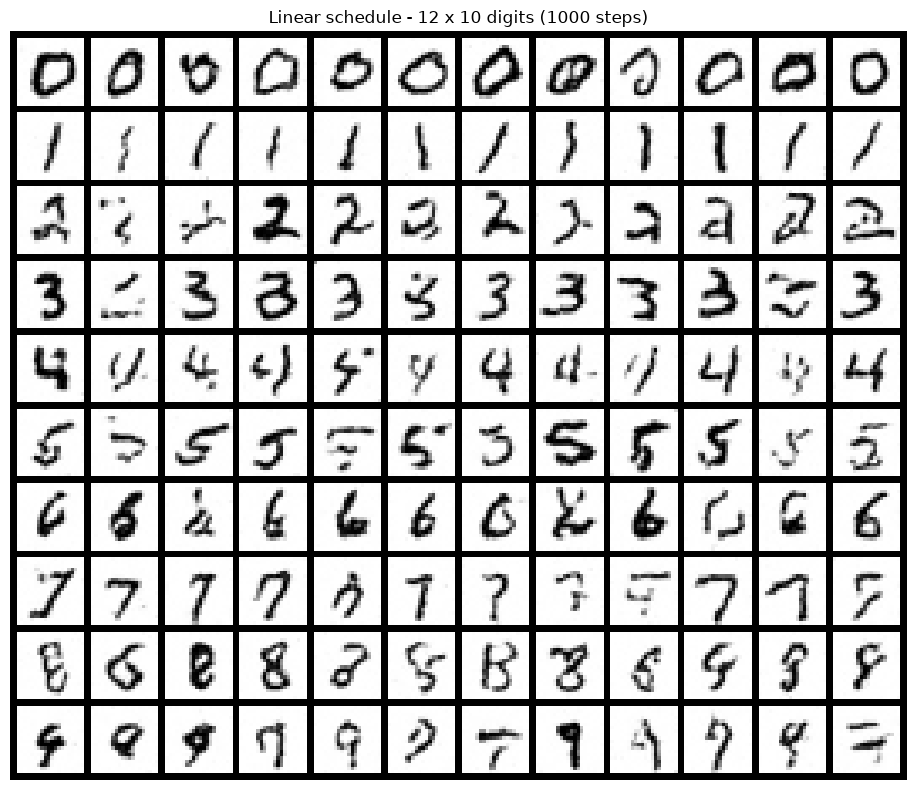

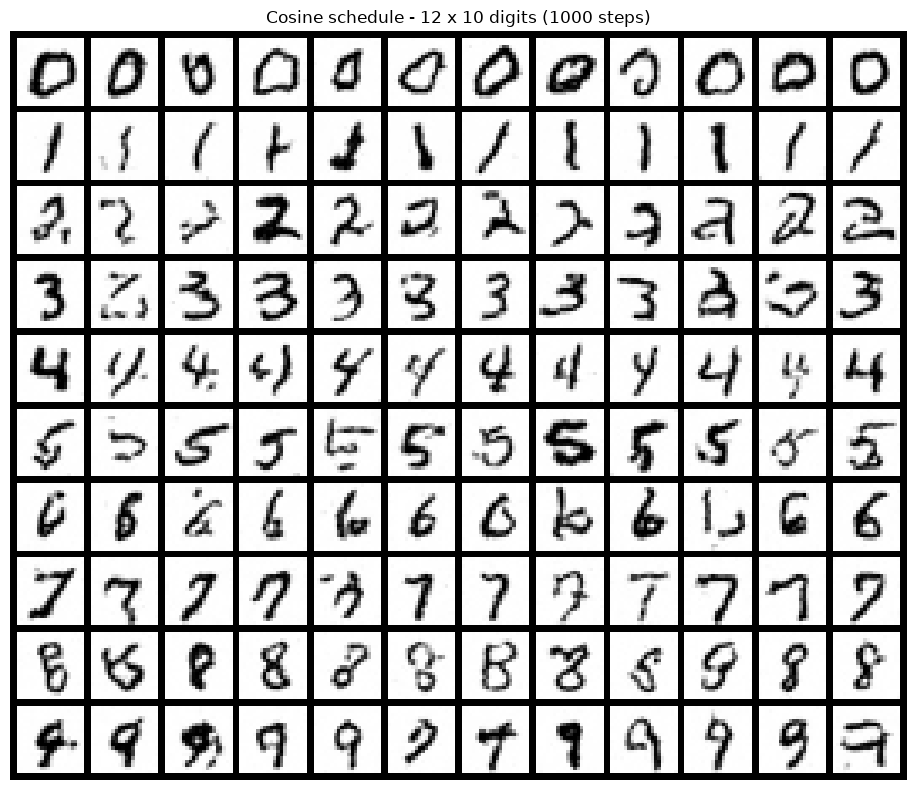

In [8]:
# ---------------------------------------------------------------------------
# Required qualitative deliverable: the 12 x 10 (120-image) conditional grid for
# BOTH schedules at full sampling steps.
# ---------------------------------------------------------------------------
full_grids = {}
for name, (m, sch) in models.items():
    g = make_digit_grid(m, sch, samples_per_digit=12, num_steps=sch["T"])
    full_grids[name] = g
    show_digit_grid(g, 12, f"{name} schedule - 12 x 10 digits ({sch['T']} steps)")

## Hypothesis test — sample quality vs number of reverse steps

Linear  |   10 steps -> recognisability 0.900


Linear  |   20 steps -> recognisability 0.882


Linear  |   50 steps -> recognisability 0.876


Linear  |  100 steps -> recognisability 0.868


Linear  |  250 steps -> recognisability 0.866


...

Cosine  |   20 steps -> recognisability 0.880


Cosine  |   50 steps -> recognisability 0.888


Cosine  |  100 steps -> recognisability 0.888


Cosine  |  250 steps -> recognisability 0.890


Cosine  | 1000 steps -> recognisability 0.890


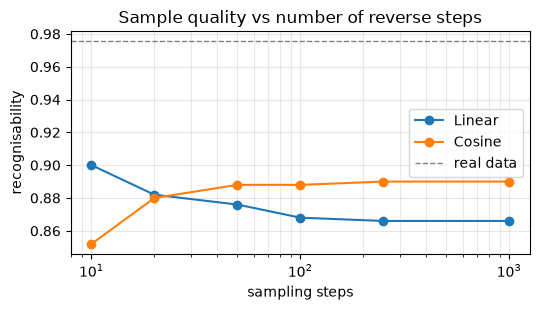

In [9]:
# ---------------------------------------------------------------------------
# Core hypothesis test: sample both models with progressively FEWER reverse
# steps and measure recognisability at each. The hypothesis predicts the cosine
# schedule keeps quality high at small step counts where the linear schedule
# collapses. We use 100 samples per digit (1000 images) at each step count for
# a stable estimate.
# ---------------------------------------------------------------------------
STEP_COUNTS = [10, 20, 50, 100, 250, 1000]
PER_DIGIT = 50    # 500 images per estimate — stable and fits the 4 GB GPU
intended = torch.arange(NUM_CLASSES, device=device).repeat_interleave(PER_DIGIT)

quality = {name: [] for name in models}
for name, (m, sch) in models.items():
    for K in STEP_COUNTS:
        imgs = sample_conditional(m, sch, intended, num_steps=K, seed=SEED)
        acc = recognisability(imgs, intended)
        quality[name].append(acc)
        print(f"{name:7s} | {K:4d} steps -> recognisability {acc:.3f}")

# Plot quality vs number of sampling steps (log-x).
plt.figure(figsize=(5.5, 3.2))
for name in models:
    plt.plot(STEP_COUNTS, quality[name], marker="o", label=name)
plt.axhline(real_acc, ls="--", c="grey", lw=1, label="real data")
plt.xscale("log"); plt.xlabel("sampling steps"); plt.ylabel("recognisability")
plt.title("Sample quality vs number of reverse steps")
plt.legend(); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.savefig("fig_quality_vs_steps.png", dpi=150, bbox_inches="tight"); plt.show()

## Few-step grids and results summary

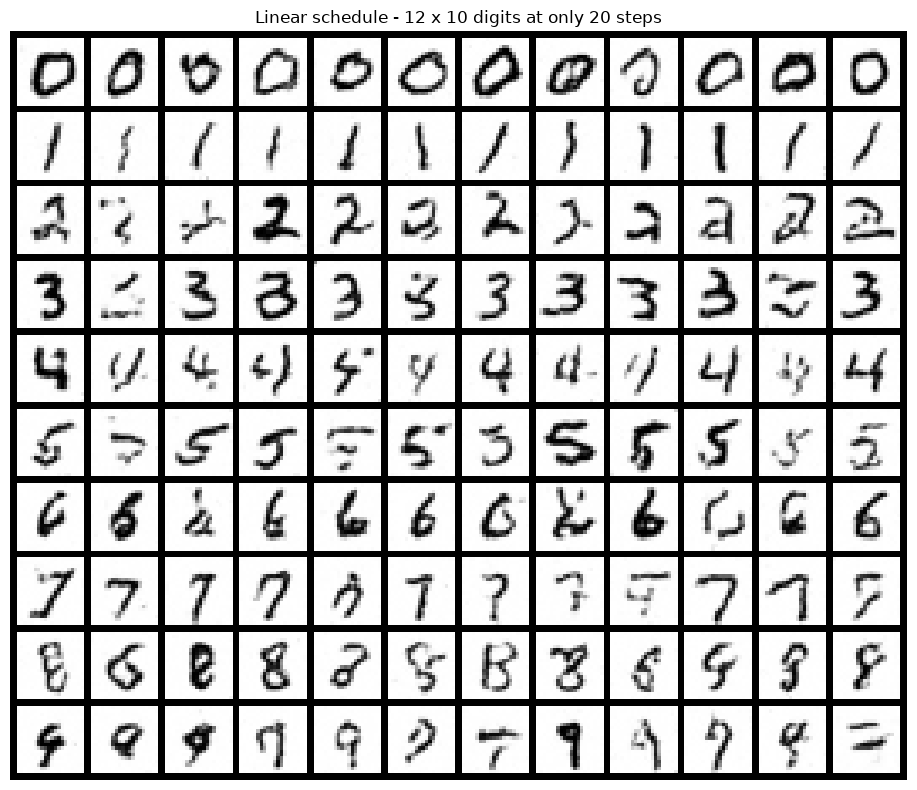

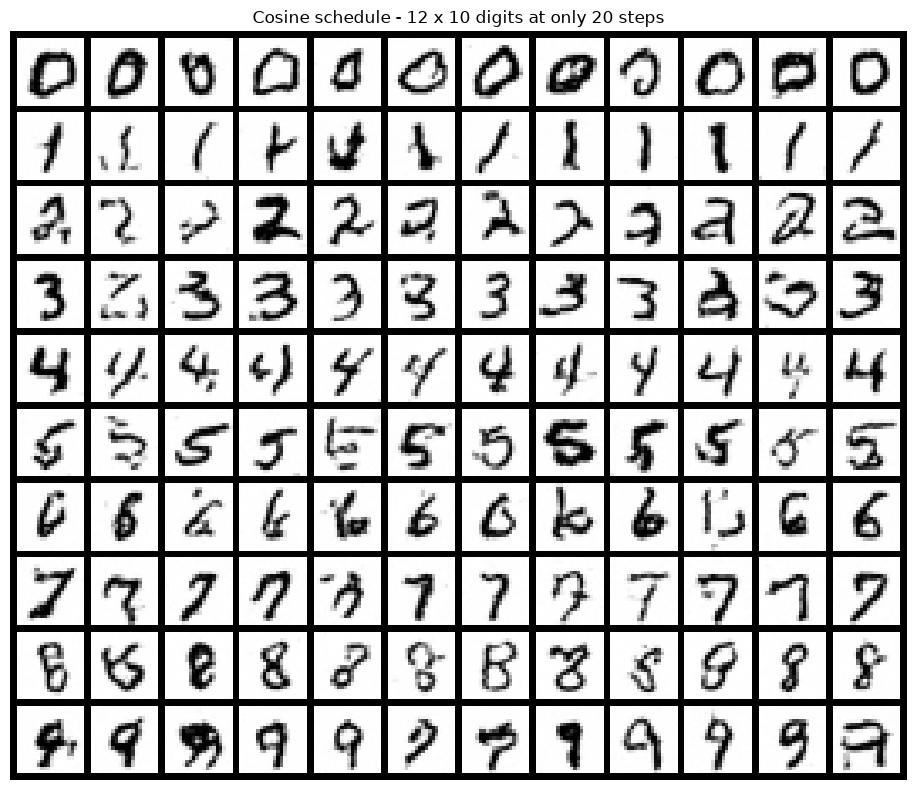

In [10]:
# Qualitative view of the hypothesis: the same digits generated with FEW steps.
FEW = 20
few_grids = {}
for name, (m, sch) in models.items():
    g = make_digit_grid(m, sch, samples_per_digit=12, num_steps=FEW)
    few_grids[name] = g
    show_digit_grid(g, 12, f"{name} schedule - 12 x 10 digits at only {FEW} steps")

{
  "full_step_quality": {
    "Linear": 0.8660000562667847,
    "Cosine": 0.89000004529953
  },
  "quality_at_20": {
    "Linear": 0.8820000290870667,
    "Cosine": 0.8800000548362732
  },
  "train_time": {
    "linear": 800.704443693161,
    "cosine": 800.8391654491425
  },
  "real_acc": 0.9753999710083008
}


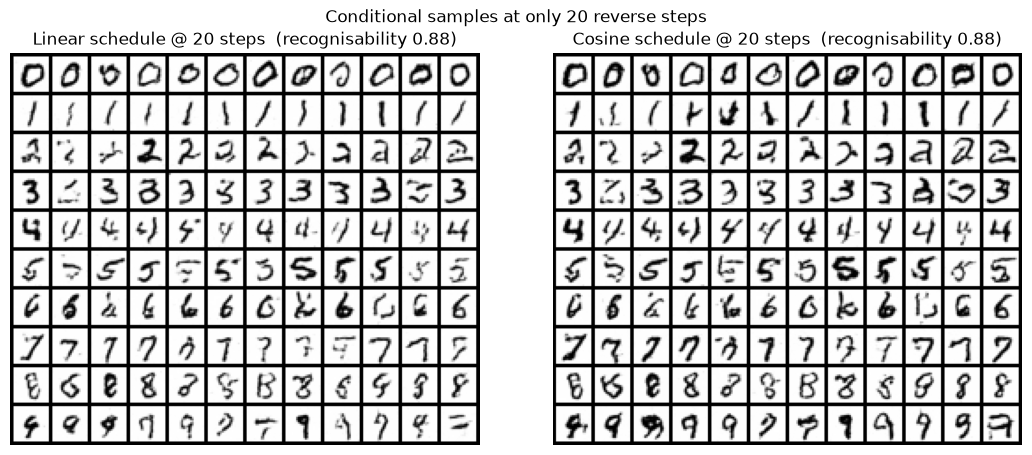

saved a7_results.json, results_summary.pkl, fig_quality_vs_steps.png, fig_fewstep_grids.png


In [11]:
# ---------------------------------------------------------------------------
# Consolidated results used by the report: training time, full-step quality, and
# the quality-vs-steps table. Everything is dumped to results_summary.pkl and a
# compact JSON so the report text is guaranteed to match the code.
# ---------------------------------------------------------------------------
import json
losses = pickle.load(open("ddpm_losses.pkl", "rb"))
# full-step quality is the 1000-step point already measured above (reuse, no resample)
full_quality = {name: quality[name][STEP_COUNTS.index(1000)] for name in models}

summary = {
    "step_counts": STEP_COUNTS,
    "quality_vs_steps": quality,
    "full_step_quality": full_quality,
    "real_acc": real_acc,
    "train_time": {k: losses[k]["time"] for k in losses},
    "final_loss": {k: losses[k]["loss"][-1] for k in losses},
}
# recognisability at a deliberately small budget (headline number)
small = STEP_COUNTS.index(20)
summary["quality_at_20"] = {name: quality[name][small] for name in models}
json.dump(summary, open("a7_results.json", "w"), indent=2)
with open("results_summary.pkl", "wb") as fh:
    pickle.dump(summary, fh)

print(json.dumps({k: summary[k] for k in
      ["full_step_quality", "quality_at_20", "train_time", "real_acc"]}, indent=2))

# Composite figure for the report: few-step grids of both schedules side by side.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, name in zip(axes, ["Linear", "Cosine"]):
    grid = utils.make_grid(few_grids[name], nrow=12)
    ax.imshow(grid.permute(1, 2, 0)); ax.axis("off")
    ax.set_title(f"{name} schedule @ {FEW} steps  (recognisability {quality[name][small]:.2f})")
fig.suptitle("Conditional samples at only 20 reverse steps")
plt.tight_layout(); plt.savefig("fig_fewstep_grids.png", dpi=150, bbox_inches="tight"); plt.show()
print("saved a7_results.json, results_summary.pkl, fig_quality_vs_steps.png, fig_fewstep_grids.png")

### Metric 2 - Frechet distance in classifier-feature space (FID analogue)
Recognisability saturates once a digit is legible, so we also measure how close the whole generated distribution is to the real one: a Frechet distance between Gaussian fits of the classifier's 128-d penultimate features (real test digits vs generated samples). Lower is better. Using our own in-domain CNN instead of InceptionV3 keeps the metric suited to 20x20 digits and within taught tools.

Linear  |   10 steps -> Frechet distance 22.39


Linear  |   20 steps -> Frechet distance 19.81


Linear  |   50 steps -> Frechet distance 19.20


Linear  |  100 steps -> Frechet distance 19.08


Linear  |  250 steps -> Frechet distance 19.03


...

Cosine  |   20 steps -> Frechet distance 17.78


Cosine  |   50 steps -> Frechet distance 16.08


Cosine  |  100 steps -> Frechet distance 15.86


Cosine  |  250 steps -> Frechet distance 15.75


Cosine  | 1000 steps -> Frechet distance 15.71


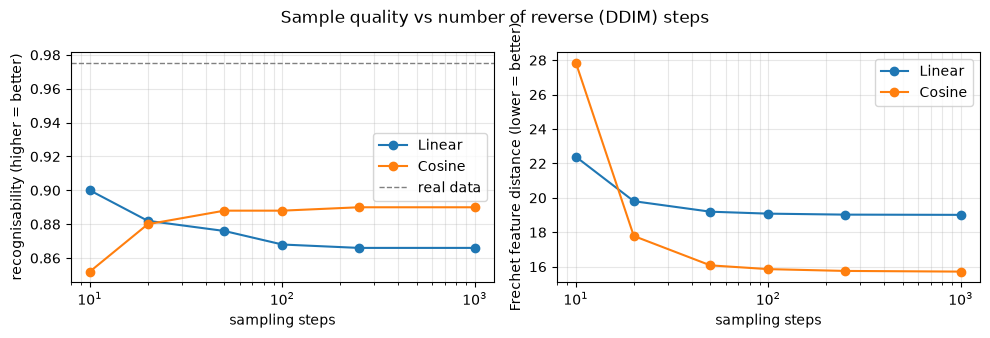

updated a7_results.json and fig_quality_vs_steps.png with Frechet distances


In [12]:
# ---------------------------------------------------------------------------
# Frechet feature distance vs number of reverse steps, for both schedules.
# Features come from the classifier's penultimate layer (everything but the
# final Linear). FD = ||mu_r - mu_g||^2 + Tr(C_r + C_g - 2 (C_r C_g)^0.5).
# ---------------------------------------------------------------------------
feat_net = classifier.net[:-1]          # 128-d feature extractor

@torch.no_grad()
def features(imgs01):
    return feat_net(imgs01.to(device)).cpu().numpy()

def frechet_distance(f_real, f_gen):
    mu_r, mu_g = f_real.mean(0), f_gen.mean(0)
    c_r, c_g = np.cov(f_real, rowvar=False), np.cov(f_gen, rowvar=False)
    covmean = np.sqrt(np.clip(np.linalg.eigvals(c_r @ c_g).real, 0, None)).sum()
    return float(((mu_r - mu_g) ** 2).sum() + np.trace(c_r) + np.trace(c_g) - 2 * covmean)

real_feats = features(test_x01[:2000])
fd = {name: [] for name in models}
for name, (m, sch) in models.items():
    for K in STEP_COUNTS:
        imgs = sample_conditional(m, sch, intended, num_steps=K, seed=SEED)
        fd[name].append(frechet_distance(real_feats, features(imgs)))
        print(f"{name:7s} | {K:4d} steps -> Frechet distance {fd[name][-1]:.2f}")

# Two-panel figure used in the report: recognisability and Frechet distance vs steps.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for name in models:
    axes[0].plot(STEP_COUNTS, quality[name], marker="o", label=name)
    axes[1].plot(STEP_COUNTS, fd[name], marker="o", label=name)
axes[0].axhline(real_acc, ls="--", c="grey", lw=1, label="real data")
axes[0].set_ylabel("recognisability (higher = better)")
axes[1].set_ylabel("Frechet feature distance (lower = better)")
for ax in axes:
    ax.set_xscale("log"); ax.set_xlabel("sampling steps"); ax.grid(alpha=0.3, which="both"); ax.legend()
fig.suptitle("Sample quality vs number of reverse (DDIM) steps")
plt.tight_layout(); plt.savefig("fig_quality_vs_steps.png", dpi=150, bbox_inches="tight"); plt.show()

summary["frechet_vs_steps"] = fd
json.dump(summary, open("a7_results.json", "w"), indent=2)
with open("results_summary.pkl", "wb") as fh:
    pickle.dump(summary, fh)
print("updated a7_results.json and fig_quality_vs_steps.png with Frechet distances")